<a href="https://colab.research.google.com/github/aakashkumar089/Class-notes/blob/main/OTS_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Why Regularization --> If model **Overfits** we go for regularisation.And to improve the generalisation of the model.



## Regularization has 2 types:-

### 1. Ridge Regularisation(L2 Regularization)

### 2. Lasso Regularization(L1 Regularization)

### In case of Underfitting increase the size of training data

## How to apply the regularisation ?

## y = 25x^2 + 5x + 2

### The variable which has highest coefficient will have the more influence

### Loss  = Error + penalty

## Ridge regression -> Penalty term
### Loss = MSE + lambda,Sigma, w^2

### ridge(alfa=1.2)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

In [2]:
data = load_diabetes()

In [3]:
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [4]:
X = data.data
y = data.target

In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression
L = LinearRegression()

In [7]:
L.fit(X_train,y_train)

LinearRegression()

In [8]:
print(L.coef_)

[  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]


In [9]:
print(L.intercept_)

151.34560453985995


In [10]:
y_pred = L.predict(X_test)

In [11]:
from sklearn.metrics import r2_score, root_mean_squared_error

In [12]:
print('R2_score',r2_score(y_test,y_pred))

R2_score 0.4526027629719195


In [13]:
("RMSE",root_mean_squared_error(y_test,y_pred))

('RMSE', 53.85344583676593)

In [14]:
from sklearn.linear_model import Ridge

In [43]:
R = Ridge(alpha=0.1)

In [44]:
R.fit(X_train,y_train)

Ridge(alpha=0.1)

In [45]:
print(R.coef_)

[  42.85566976 -205.49431899  505.08903304  317.0932049  -108.50026183
  -86.23673333 -190.36318008  151.70708637  392.28931896   79.9081772 ]


In [46]:
print(R.intercept_)

151.45857456679613


In [47]:
y_pred_ridge = R.predict(X_test)

In [48]:
print('R2_score',r2_score(y_test,y_pred_ridge))


R2_score 0.46085219464119265


In [49]:
("RMSE",root_mean_squared_error(y_test,y_pred_ridge))

('RMSE', 53.446111997699646)

In [50]:
###
m = 100
x1 = 5 * np.random.rand(m,1) - 2

x2 = 0.8* x1**2 - 2*x1  + 3 + np.random.randn(m,1)

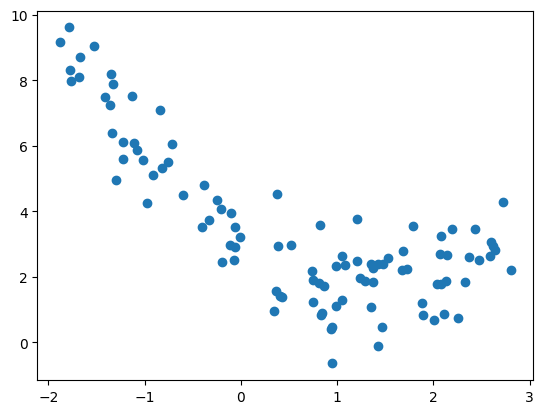

In [52]:
plt.scatter(x1,x2)
plt.show()

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

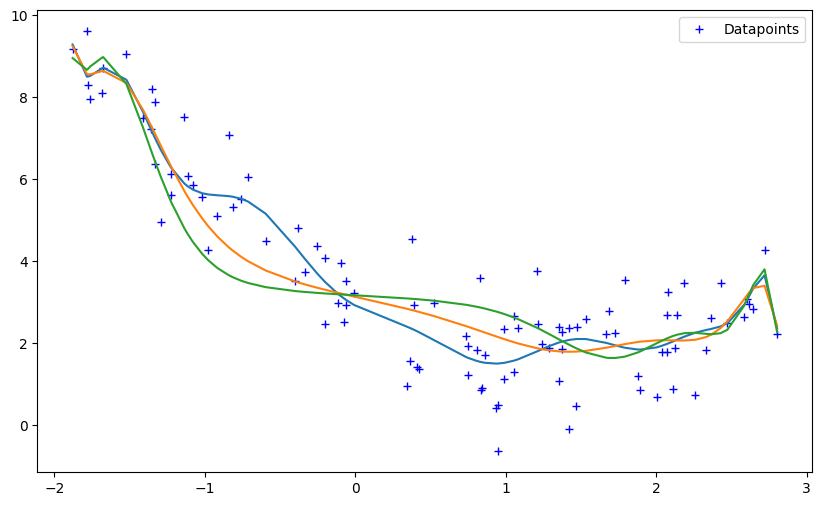

In [73]:
from sklearn import pipeline
def get_preds(x1,x2,alpha):
    model = Pipeline([
        ('poly_feats',PolynomialFeatures(degree=15)),
        ('ridge', Ridge(alpha = alpha))
    ])

    model.fit(x1,x2)
    return model.predict(x1)


alpha = [0,20,200]
cs = ['r','b','g']


plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label= 'Datapoints')


for alpha,c in zip(alpha,cs):
    preds = get_preds(x1,x2,alpha)
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0]),]),c


plt.legend()
plt.show()

In [ ]:
,